# Approximate Hybrid Quantum State Preparation for a Sinc Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## Signal Generation

A sinc signal is generated as a representative smooth non-periodic waveform for transform-domain sparsity analysis.

In [3]:
n = 10    # Number of qubit
N = 2**n  # Number of quantum basis

t = np.linspace(-10, 10, N)

# create sinc signal
x = np.sinc(t)

target_f =  x / np.linalg.norm(x)

### Visualization of the Sinc Signal

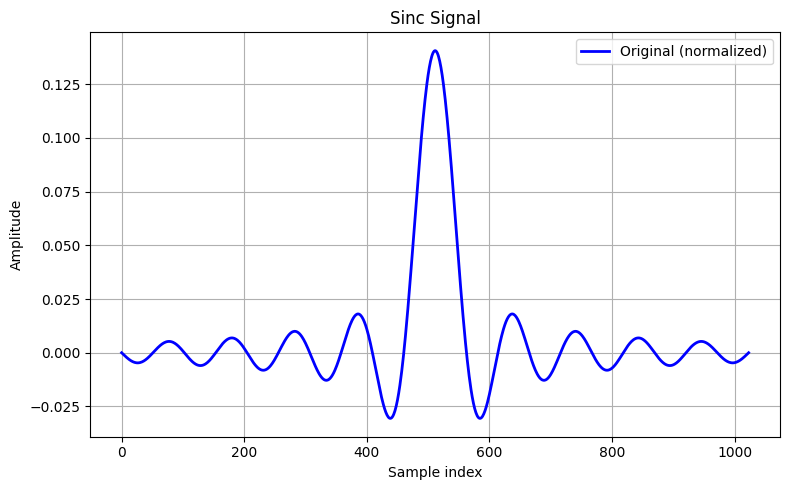

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Sinc Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Compression of the Sinc Signal

### Classical Sparsity Analysis

The transform-domain coefficients are analyzed in order to identify sparse representations suitable for quantum state preparation.

In [5]:
results = search_sparse_haar_representations(
    x,
    tolerance=0.04
)

Level=5 | Threshold=4.575e-03 | Nonzero=324 | Sparsity=0.316 | Trace Distance=5.401470e-03 | Fidelity=0.999971
Level=5 | Threshold=9.150e-03 | Nonzero=244 | Sparsity=0.238 | Trace Distance=1.028043e-02 | Fidelity=0.999894
Level=5 | Threshold=2.287e-02 | Nonzero=158 | Sparsity=0.154 | Trace Distance=2.234717e-02 | Fidelity=0.999501
Level=6 | Threshold=3.604e-03 | Nonzero=350 | Sparsity=0.342 | Trace Distance=4.127997e-03 | Fidelity=0.999983
Level=6 | Threshold=7.209e-03 | Nonzero=266 | Sparsity=0.260 | Trace Distance=7.945041e-03 | Fidelity=0.999937
Level=6 | Threshold=1.802e-02 | Nonzero=170 | Sparsity=0.166 | Trace Distance=1.801738e-02 | Fidelity=0.999675
Level=6 | Threshold=3.604e-02 | Nonzero=112 | Sparsity=0.109 | Trace Distance=3.351818e-02 | Fidelity=0.998877
Level=7 | Threshold=2.857e-03 | Nonzero=358 | Sparsity=0.350 | Trace Distance=3.338950e-03 | Fidelity=0.999989
Level=7 | Threshold=5.714e-03 | Nonzero=266 | Sparsity=0.260 | Trace Distance=6.786680e-03 | Fidelity=0.999954
L

In [7]:
# Apply 10-level discrete packet Haar wavelet transformation on sinc signal
level = 6
X = haar_packet_transform(x, level)

### Top-k Sparsification

To obtain a sparse transform-domain representation suitable for sparse quantum state preparation, only the largest \(k=110\) Haar-domain coefficients are retained while the remaining coefficients are discarded.

In [17]:
k = 98
Xr = top_k_threshold(X, k)

### Normalization
The `X_norm` is the output of Phase I.

In [18]:
X_norm = Xr/np.linalg.norm(Xr)

### Classical Signal Reconstruction

In [19]:
x_rec = inverse_haar_packet_transform(X_norm, level)

### Trace Distance

In [20]:
TD = trace_distance(x_rec, target_f)

### Visualization

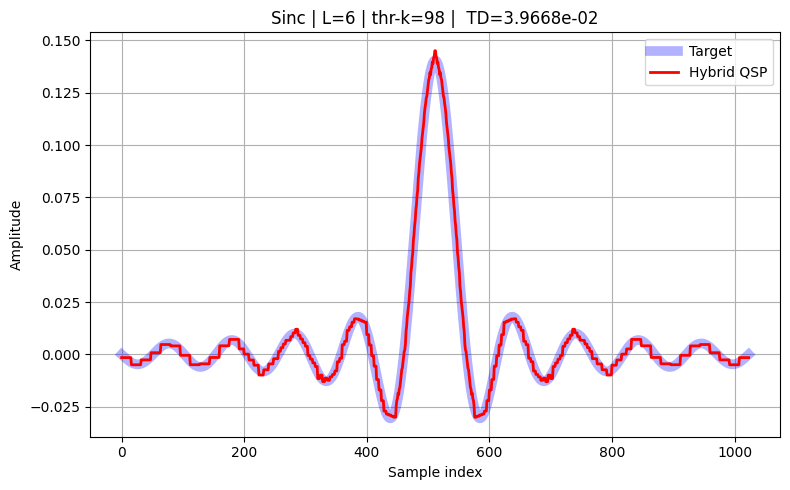

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Target")
plt.plot(x_rec, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Sinc | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();

plt.savefig("../figures/Sinc_signal_preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [22]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [23]:
# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Number of qubits required for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias sparse state preparation method
qc = sparse_encoder(
    y,
    method="farias"
)

# Construct inverse quantum Haar packet
# wavelet transform circuit
iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

# Apply inverse quantum transformation
# for signal reconstruction
qc.add(
    iqphwt.on_qubits(*range(nqubits))
)

# Print the decomposed circuit statistics
print(
    qc.decompose().decompose().summary()
)

[Qibo 0.3.4|INFO|2026-07-02 00:16:56]: Using numpy backend on /CPU:0


Circuit depth = 741
Total number of gates = 1104
Number of qubits = 10
Most common gates:
cx: 581
x: 284
ry: 197
h: 42
None


### Statevector of the Quantum SQSP and Quantum Decompression

In [24]:
result = qc()

state = result.state()

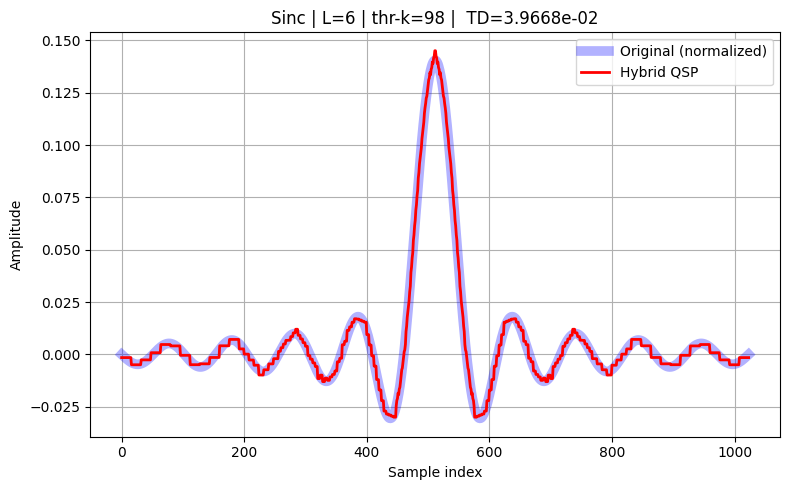

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Sinc | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()